#### Naive Bayes - Classification algorithm based on Bayes' Theorem(conditoin based theorem)
##### Naive- Occurance of a certain feature is independent of the occurance of other features.
##### Bayes- It depends on the priciple of Bayes' Theorem.


##### P(R or B) = P(R)*P(B/R)

##### Jab B event ho jaye to A ki Chance is given by 

##### P(A/B) = P(B/A)*P(A)/P(B)

#### Types-
##### (1)Gaussian Naive Bayes: Suitable for features that are continuous and have a normal distribution.
##### (2) Bernoulli Naive Bayes: Assume features are binary(Boolean) variables. Suitable for data that can be represented as binary features, such as document classification problems .(when one-Hot encoding krte h 0 or 1)
##### (3)Multinomial Naive Bayes: Features follow a mutlinomial distribution. Used for discrete data, such as text data , where each features represents the frequency of a term.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [4]:
dataset = pd.read_csv("placement_data.csv")
dataset.head(3)

,CGPA,Score,Placed
0,6.87,419,0
1,9.75,362,1
2,8.66,419,1


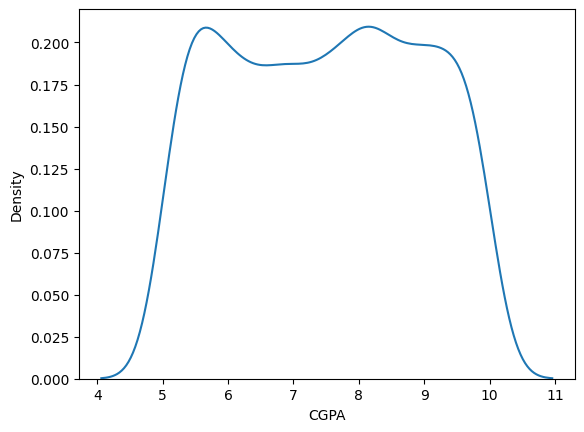

In [ ]:
# checking the distribution of data so that we can decide which type of Naive Bayes to use
sns.kdeplot(data =dataset["CGPA"])
plt.show()

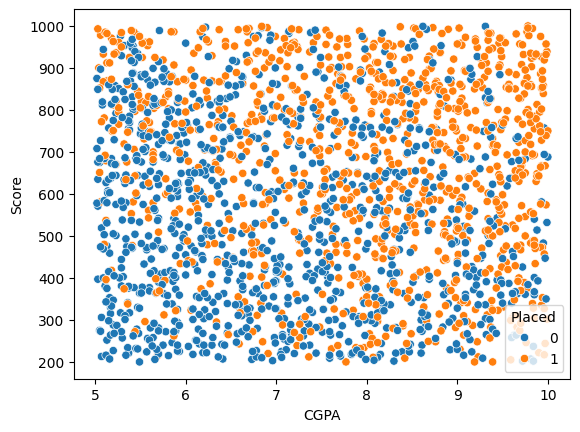

In [5]:
sns.scatterplot(data=dataset, x="CGPA", y="Score", hue="Placed")
plt.show()

In [6]:
x = dataset.iloc[:,:-1]
y = dataset["Placed"]

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
# According to the distribution of data we can use GaussianNB but we will try all the three types of Naive Bayes
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

In [16]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [17]:
gnb.score(x_test, y_test)*100

65.0

In [30]:
# Lets predict
gnb.predict([[9.75	,362]])

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

In [18]:
# In train
gnb.score(x_train, y_train)*100



67.5625

In [19]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [20]:
mnb.score(x_test, y_test)*100

59.25

In [22]:
mnb.score(x_train, y_train)*100

55.125

In [23]:
bnb = BernoulliNB()
bnb.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [24]:
bnb.score(x_test, y_test)*100

50.0

In [25]:
bnb.score(x_train, y_train)*100

51.125

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


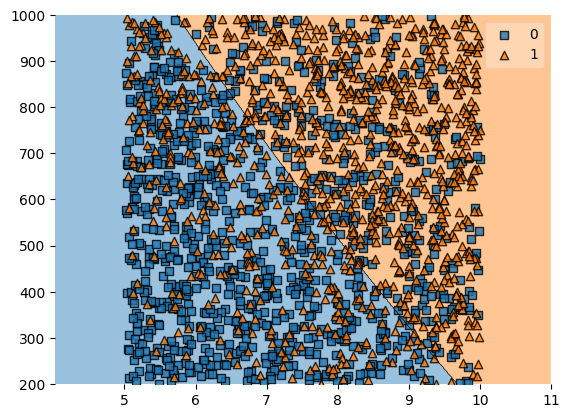

In [26]:
# Decision Region for GaussianNB
plot_decision_regions(np.array(x), np.array(y), clf=gnb)
plt.show()

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


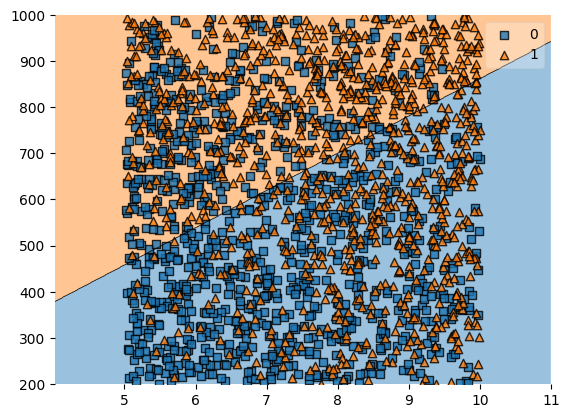

In [27]:
# for MultinomialNB
plot_decision_regions(np.array(x), np.array(y), clf=mnb)
plt.show()

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


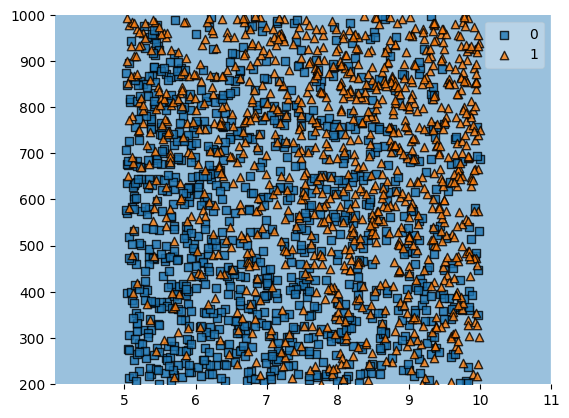

In [29]:
# for bernoulliNB
plot_decision_regions(np.array(x), np.array(y), clf=bnb)
plt.show()

#### From here we can see that Gausian Works better as it is suitable for Normal Distribution